# 01 — Can gas exchange explain ocean carbon storage?

**Learning goals:** map boxes and arrows to a conserved carbon inventory;
distinguish implementation checks from physical assumptions; distinguish
equilibrium controls from rate controls.

You have just started working with ESBMTK and want to check your first
atmosphere–ocean model. You devise a fictional experiment with two reservoirs:
an atmosphere and one well-mixed ocean box. This is a redistribution experiment,
not a history of ocean formation.

Initially, almost all carbon is in the atmosphere. You represent the ocean as
idealized saline water with no background alkalinity (**TA = 0**), retaining
only a very small initial DIC concentration for numerical purposes. The system
exchanges CO2 internally but receives no carbon or alkalinity from outside.
The supplied calculations retain seawater chemistry settings; this is not a
literal pure-NaCl chemical composition.

You choose the total carbon inventory to equal the combined inventory of an
atmosphere at **280 ppm CO2** and an ocean with **DIC = 2040 µmol/kg**.
Your working expectation is: **if the model is coded correctly, gas exchange
should eventually reproduce these two familiar course reference values.**
Treat this expectation as a hypothesis to examine during the experiment.

**Core time: 35 minutes.** Diagram and prediction (10); diagnose and revise the
model (15); compare paths and explain (10). Setup, plotting and audits are supplied.
Only the input-pair selection below requires code. Use short answers, not a report.
Teaching goals and timing: [TEACHING_GOALS.md](../../TEACHING_GOALS.md).

**Coding reference:** [From conceptual model to code](../../ref/modelling_cheatsheet.md)
([two-page handout](../../output/pdf/modelling_cheatsheet.pdf)). Keep it beside this notebook.
Code labels show where to focus: **Choose and explain** = complete the marked
scientific choices; **Understand and run** = trace the supplied model and read
its evidence; **Supplied implementation** = run the supporting machinery as provided.
The labels also apply to surrounding predictions and explanations: supplied code
can still require scientific interpretation. Syntax memorisation is not assessed.
Use the guide to orient yourself during the existing diagram/worked-example
activity; the separate tracer example is optional reference, not extra work.


In [1]:
# Supplied implementation: run this support code as provided.
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import PyCO2SYS as pyco2

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'teaching_config.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from teaching_config import TEACHING as C
from simple_models import (
    new_model, box_parameters, box_mass_kg, connect_atmosphere,
    single_box, inventories, audit,
)
from esbmtk import initialize_reservoirs, add_carbonate_system_1
from model import run_model
from teaching_plots import plot_ta_free, plot_partition_comparison, settling_time

## 1. Specify the system before building it

```text
Atmosphere (xCO2; GasReservoir)
            ↕ gas exchange: carbon only (Species2Species)
Ocean (DIC, TA; initialize_reservoirs)
      carbonate system 1 → aqueous CO2
```

Both boxes lie inside the system boundary. Define gas flux $J_{gas}(t)$ positive
into the ocean. Then $dC_{atm}/dt=-J_{gas}(t)$ and
$m_o\,dDIC_o(t)/dt=J_{gas}(t)$; the TA inventory has zero tendency.

| Quantity | Status |
| --- | --- |
| 280 ppm dry-air xCO2; 2040 µmol/kg DIC | Observed comparison targets |
| Area, 3750 m ocean depth, atmospheric mole inventory, T/S/P | Independent inputs |
| Total carbon computed from those sizes and targets | Target-derived inventory |
| Initial carbon partition | Fictional initial condition |
| Initial TA = 0 | Prescribed physical assumption |

Uniform T = 16 °C, S = 35, P = 0 bar and carbonate choices are supplied by
`teaching_config.py`. ESBMTK uses bar; PyCO2SYS uses dbar. Seawater density comes
from ESBMTK at these conditions. No geometry is fitted to a carbon ratio.

$$C_0=N_{atm}(280\times10^{-6})+\rho V_o(2040\times10^{-6}).$$

In [2]:
# Understand and run: trace this supplied step and interpret its evidence.
print('Shared chemistry:', C.pyco2)
print('Ocean volume (m3):', C.ocean_volume_m3)
print('ESBMTK density (kg/m3):', C.density_kg_m3)
print('Target-derived total carbon (mol):', C.total_carbon_mol)
INITIAL_DIC = 0.01  # umol/kg, small positive numerical seed
FIRST_TA = 0.0      # umol/kg: no background alkalinity

Shared chemistry: {'opt_k_carbonic': 10, 'opt_pH_scale': 2, 'opt_buffers_mode': 1, 'temperature': 16.0, 'salinity': 35.0, 'pressure': 0.0}
Ocean volume (m3): 1.35e+18
ESBMTK density (kg/m3): 1025.7484950008022
Target-derived total carbon (mol): 2.8744713552322094e+18


## 2. Supplied example: translate the diagram into objects

`Model` supplies the clock and units. `initialize_reservoirs` creates DIC and TA
states; `add_carbonate_system_1` supplies aqueous CO2 for gas exchange.
The atmospheric mole fraction is calculated from the carbon remaining after
initializing the ocean. Gas exchange is bidirectional even though its positive
direction is atmosphere to ocean.

![Atmosphere-ocean code map: GasReservoir and Ocean states connected by reversible gas exchange, with dashed information links from the supplied carbonate calculation.](../../ref/figures/01_air_sea_code_map.png)

**Read the code labels beside each element.** `M.CO2` is a species definition;
`M.CO2_At` is the atmospheric state, and `M.Ocean.DIC` is the ocean DIC state.
The `.c` attribute stores concentration values (atmospheric mole fraction or
ocean mol/kg); `[0]` and `[-1]` select the first and last saved values.
The helper `connect_atmosphere` constructs the labelled native gas connection
and returns it as `exchange`. Its `species=M.CO2` describes the exchanged gas,
while `sink=M.Ocean.DIC` identifies the ocean state it changes.

Solid arrows carry carbon; dashed arrows carry information used to calculate
the gas flux. `M.Ocean.CO2aq` is derived by carbonate chemistry and supplied as
`ref_species`, not another independent carbon inventory. Geometry and T/S/P
enter via the `g`, `T`, `S`, `P` fields returned by `box_parameters`; the `c`
dictionary supplies initial DIC and TA. Water mass is volume times ESBMTK density.
Trace these existing steps during the diagram check below; no extra answer is required.

**Diagram check (before running):** point to the ocean DIC/TA states and the
gas connection in the code. Which quantity is calculated from DIC and TA?
Add the two carbon tendencies above: why do internal transfers cancel, and
why is concentration multiplied by water mass when checking inventory?

<!-- BEGIN SOLUTION -->
`M.Ocean.DIC` and `M.Ocean.TA` are states; carbonate chemistry calculates
aqueous CO2. `connect_atmosphere` creates the atmosphere and its gas connection.
The ocean gains exactly what the atmosphere loses, so their carbon sum is
constant. mol/kg times kg is mol. TA has no source or sink in this model.
<!-- END SOLUTION -->

In [3]:
# Understand and run: trace this supplied step and interpret its evidence.
M = new_model(stop='2 kyr', max_timestep='1 yr')
initialize_reservoirs(M, {'Ocean': box_parameters(
    M, C.ocean_volume_m3, INITIAL_DIC, FIRST_TA)})
add_carbonate_system_1([M.Ocean])
# Supplied helper creates GasReservoir and the native gasexchange connection.
# Inspect its short definition in simple_models.py alongside this diagram.
exchange = connect_atmosphere(M, [M.Ocean])
assert exchange.source is M.CO2_At and exchange.sink is M.Ocean.DIC
np.testing.assert_allclose(box_mass_kg(M.Ocean),
                           C.ocean_volume_m3 * C.density_kg_m3, rtol=1e-12)
assert M.Ocean.TA.c[0] == 0
print('Initial atmosphere (ppm):', M.CO2_At.c[0] * 1e6)
print('Initial ocean carbon fraction:',
      box_mass_kg(M.Ocean) * M.Ocean.DIC.c[0] / C.total_carbon_mol)


ESBMTK 0.14.3.1.post0  
 Copyright (C) 2020 - 2026  Ulrich G.Wortmann
This program comes with ABSOLUTELY NO WARRANTY
This is free software, and you are welcome to redistribute it
under certain conditions; See the LICENSE file for details.

If you use ESBMTK for your research, please cite:

Wortmann et al. 2025, https://doi.org/10.5194/gmd-18-1155-2025

Initial atmosphere (ppm): 16239.872924449308
Initial ocean carbon fraction: 4.817443964889389e-06


### Predict before running

Is your expectation that correct code should reproduce both reference values
justified? What does specifying the total carbon inventory constrain, and what
might determine its final partition between atmosphere and ocean?
Write a short prediction before running the next cell; revisit it afterward.

status=0
message=The solver successfully reached the end of the integration interval.


 Execution took 0.56 CPU seconds, wall time = 0.61 seconds

{'carbon_relative_error': 3.562394170796242e-16, 'ta_change_mol': 0.0}
TA-free result: xCO2 (ppm), DIC (umol/kg): 12561.780484274073 470.14355510736226


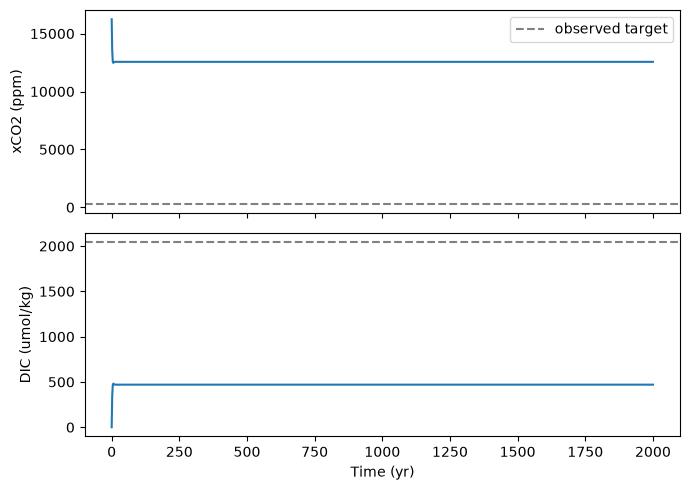

In [4]:
# Understand and run: trace this supplied step and interpret its evidence.
run_model(M)
print(audit(M))
print('TA-free result: xCO2 (ppm), DIC (umol/kg):',
      M.CO2_At.c[-1] * 1e6, M.Ocean.DIC.c[-1] * 1e6)
plot_ta_free(M, C)

### Diagnose after running

Does disagreement with the reference values demonstrate a coding error?
Revisit your prediction and use the carbon and TA budgets to support your answer.
What do passing budget checks establish, and what do they leave untested?

<!-- BEGIN SOLUTION -->
Disagreement alone does not demonstrate a coding error. The prescribed total
carbon fixes the combined inventory, not its equilibrium partition. At fixed
geometry and thermodynamic settings, that partition also depends on TA.
Gas exchange adds DIC but no TA, so the initial TA = 0 persists. With zero TA,
much more of the DIC is aqueous CO2 than in the buffered reference state, and
the ocean cannot take up the target inventory at 280 ppm. No arrow in this model
can generate the missing alkalinity. A small initial DIC does not require zero TA;
these are separate initial assumptions.

Passing carbon and TA audits supports correct budget implementation but does
not establish that every part of the code is correct or that the physical
assumptions represent the ocean. TA = 0 is a useful controlled experiment;
matching total carbon alone does not justify expecting the reference partition.
<!-- END SOLUTION -->

## 3. Exercise: infer the missing TA, then check the implementation

Only now use PyCO2SYS with target DIC and dry-air xCO2 to infer TA under the
shared conditions. Keep the same total carbon, geometry, initial DIC and piston
velocity for the buffered rerun. This is a **calibration and software-consistency
check**, not an independent prediction of TA or atmospheric xCO2.

**Exercise 01.1:** assign `dic_input_type` and `air_input_type` using this
small key: 1 = TA (umol/kg), 2 = DIC (umol/kg), 4 = pCO2 (uatm),
9 = dry-air xCO2 (ppm). The target quantities and thermodynamic settings are
already supplied. Read the inferred TA, then explain what was fitted.

In [6]:
# Choose and explain: complete marked choices; surrounding machinery is supplied.
# Verify the diagnosed mismatch before the calibrated rerun.
assert abs(M.CO2_At.c[-1] * 1e6 - C.target_xco2_ppm) > 1000
# Complete only the two input-type choices.
# BEGIN SOLUTION
dic_input_type = 2
air_input_type = 9
# END SOLUTION
reference = pyco2.sys(par1=C.target_dic_umol_kg, par1_type=dic_input_type,
                     par2=C.target_xco2_ppm, par2_type=air_input_type, **C.pyco2)
inferred_ta = float(reference['alkalinity'])
buffered = single_box(ta_umol_kg=inferred_ta)
run_model(buffered)
print('Inferred TA (umol/kg):', inferred_ta)
print(audit(buffered))
np.testing.assert_allclose(buffered.CO2_At.c[-1] * 1e6, 280, atol=0.5)
np.testing.assert_allclose(buffered.Ocean.DIC.c[-1] * 1e6, 2040, atol=0.2)


ESBMTK 0.14.3.1.post0  
 Copyright (C) 2020 - 2026  Ulrich G.Wortmann
This program comes with ABSOLUTELY NO WARRANTY
This is free software, and you are welcome to redistribute it
under certain conditions; See the LICENSE file for details.

If you use ESBMTK for your research, please cite:

Wortmann et al. 2025, https://doi.org/10.5194/gmd-18-1155-2025

status=0
message=The solver successfully reached the end of the integration interval.


 Execution took 0.62 CPU seconds, wall time = 0.63 seconds

Inferred TA (umol/kg): 2348.2362117173566
{'carbon_relative_error': 1.6030773768583089e-15, 'ta_change_mol': 0.0}


## 4. Supplied comparison: change the path while retaining the inventory

Predict the effect of (a) starting with 1000 umol/kg ocean DIC at the same total
carbon and TA, and (b) halving piston velocity. Then run the supplied comparison.
Read the shared endpoint and the different settling times from one figure.
The code audits carbon and TA at every stored time; you do not need to implement
the audit. Which change affects the relaxation rate, and which changes the
initial partition? Do either change the final equilibrium?


ESBMTK 0.14.3.1.post0  
 Copyright (C) 2020 - 2026  Ulrich G.Wortmann
This program comes with ABSOLUTELY NO WARRANTY
This is free software, and you are welcome to redistribute it
under certain conditions; See the LICENSE file for details.

If you use ESBMTK for your research, please cite:

Wortmann et al. 2025, https://doi.org/10.5194/gmd-18-1155-2025


ESBMTK 0.14.3.1.post0  
 Copyright (C) 2020 - 2026  Ulrich G.Wortmann
This program comes with ABSOLUTELY NO WARRANTY
This is free software, and you are welcome to redistribute it
under certain conditions; See the LICENSE file for details.

If you use ESBMTK for your research, please cite:

Wortmann et al. 2025, https://doi.org/10.5194/gmd-18-1155-2025

status=0
message=The solver successfully reached the end of the integration interval.


 Execution took 0.53 CPU seconds, wall time = 0.54 seconds

{'carbon_relative_error': 2.137436502477746e-15, 'ta_change_mol': 0.0}
status=0
message=The solver successfully reached the end of the integ

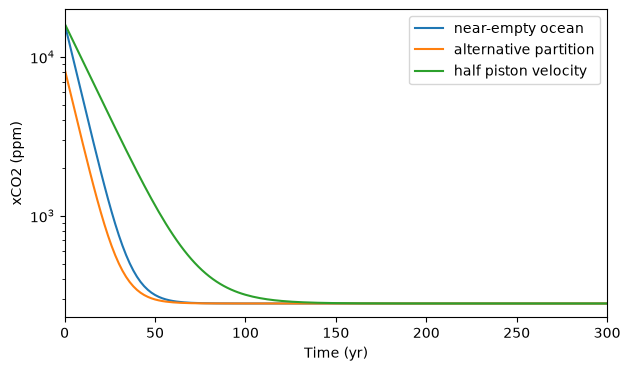

In [7]:
# Understand and run: trace this supplied step and interpret its evidence.
partition = single_box(ta_umol_kg=inferred_ta, initial_dic_umol_kg=1000)
slower = single_box(ta_umol_kg=inferred_ta, piston_velocity='2 m/d')
for case in (partition, slower):
    run_model(case)
    carbon, ta = inventories(case)
    np.testing.assert_allclose(carbon, C.total_carbon_mol, rtol=2e-6)
    np.testing.assert_allclose(ta, ta[0], rtol=2e-6)
    np.testing.assert_allclose(case.CO2_At.c[-1], buffered.CO2_At.c[-1], atol=0.5e-6)
    print(audit(case))

plot_partition_comparison(buffered, partition, slower)
assert settling_time(slower) > settling_time(buffered)


## 5. Explain the model boundary

Why do the equilibria agree although the paths differ? Where does real ocean
TA come from, and why is that not simulated here?

<!-- BEGIN SOLUTION -->
At fixed total carbon, TA, geometry and chemistry, gas-exchange equilibrium
does not depend on the initial partition or a positive piston velocity.
Piston velocity controls relaxation. Real ocean alkalinity reflects processes
including weathering, mineral dissolution and carbonate burial. Supplying
inferred TA is a closed-model calibration; it does not model those processes.
They enter explicitly in 03/04.
<!-- END SOLUTION -->

**Numerical note.** A 0.01 µmol/kg DIC seed is feasible with TA exactly zero;
it is not hidden buffering. ESBMTK's carbonate-system-1 approximation can show
transient pH discrepancies in extreme states (paper section 2.4). This exercise
checks carbon/TA conservation and stationary agreement; do not interpret its
extreme transient pH as a realistic seawater history. The gas-exchange helper
uses PyCO2SYS's dry-air conversion and ESBMTK density consistently, including
the native gas-exchange routine's factor-of-1000 convention.

**Finish 01:** explain in three sentences why the TA-free mismatch alone does
not demonstrate a coding error, what the inferred TA means, and why changing
piston velocity changes the path.
Continue to 02; the next model retains this same carbon inventory.